# W15 · Sim2Real I：域随机化（Domain Randomization）

> 阶段二（M5–M6）：MotrixLab —— 国产 Sim2Real 能力 · 第 3/6 讲

仿真里训练得再好，装上真机就「翻车」——这是机器人 RL 的世纪难题，叫 **reality gap**。
本讲讲 Sim2Real 武器库中应用最广的一件：**域随机化**。我们将用 Gymnasium 的 CartPole
真实复现完整实验：标称训练 → 参数扰动下性能崩塌 → 随机化训练 → 鲁棒性对比，
然后再看 MotrixSim 官方的参数随机化 API 长什么样。

## 学习目标

1. 解释 reality gap 的来源，并用「分布外泛化」的语言描述它；
2. 写出域随机化的数学形式：在参数分布 $p(\xi)$ 上最大化期望回报；
3. 动手实现「每次 reset 随机采样物理参数」的训练流程，并用热力图量化鲁棒性；
4. 说出机器人任务中常见的可随机化参数（质量/质心/摩擦/电枢/增益/重力）及范围确定原则；
5. 了解 MotrixSim 的 override API 设计（作用于 `SceneData`，不改动模型本身）。

> **本讲可执行性说明**：DR 原理实验用纯 Gymnasium + SB3 真实执行（两次训练，CPU 共约 6–10 分钟）；
> MotrixSim override API 的 cell 标注运行前提，保持未执行。

## 3.1 Reality gap：仿真和现实的差距在哪

仿真器里的机器人是「理想化」的：质量精确等于 CAD 标称值、摩擦系数是拍脑袋的常数、
电机响应瞬时到位、传感器分毫不差。真实机器人则处处是偏差：

- **参数偏差**：装配误差让真实质量/质心偏离标称值（±10% 很常见）；电池电量影响推力；
- **未建模动态**：齿轮间隙、皮带弹性、线缆拖拽力、关节摩擦的温度漂移；
- **接触建模误差**：鞋底与地面的摩擦随材质、湿度、磨损变化，是最难建准的部分。

**直觉类比**：只在标准场地练车的学员，第一次上雨雪路面必然手忙脚乱。
reality gap 的本质是**过拟合**——策略过拟合到了「仿真器这一个具体的动力学参数组合」上。
用机器学习的语言：训练分布（单一参数）与测试分布（真实世界的参数）不一致。

两条互补的应对路线：

| 路线 | 思想 | 本阶段安排 |
|------|------|-----------|
| **域随机化（DR）** | 训练时把参数随机化，让策略对「一整片参数区域」都有效 | 本讲（W15） |
| **系统辨识（SysID）** | 把仿真参数测准，从源头缩小 gap | W17 |

工程实践里两者永远搭配使用：SysID 给出标称值和不确定度，DR 在这个范围内随机化。

## 3.2 数学形式：从单点训练到分布训练

普通 RL 在一个固定环境（一组固定动力学参数 $\xi$）中最大化回报：

$$
\pi^* = \arg\max_\pi \; J(\pi; \xi_0), \qquad
J(\pi; \xi) = \mathbb{E}\left[\sum_t \gamma^t r_t \,\Big|\, \pi, \xi\right]
$$

域随机化把 $\xi$ 从常量变成**随机变量**：每个 episode 从分布 $p(\xi)$ 中重新采样一组
物理参数（质量、摩擦……），优化目标变成在参数分布上的**期望回报**：

$$
\pi^* = \arg\max_\pi \; \mathbb{E}_{\xi \sim p(\xi)} \left[ J(\pi; \xi) \right]
$$

这和监督学习里的**数据增强**是同一种思想：图像分类时对训练图随机裁剪/调色，
模型就无法依赖「猫永远在画面正中央」这种巧合特征；DR 让策略无法依赖
「质量恰好是 1.0 kg」这种巧合动力学。**代价**也很直白：策略要兼顾的环境变多了，
在任何一个单一环境上的性能通常会比「专门针对它训练」略低——鲁棒性与最优性的交换。

可并行仿真是 DR 的绝配：batch 中每个环境实例采样**不同**的参数，
一次 rollout 就覆盖了参数空间的一整片区域（这正是 MotrixSim override API 的设计动机）。

## 3.3 动手实验：CartPole 上的域随机化

Gymnasium 的 CartPole 动力学参数（杆质量 `masspole`、半杆长 `length`、推力 `force_mag` 等）
是环境的普通属性，可以直接改写——正好用来模拟「真机参数与训练参数不一致」。

实验设计（控制变量）：

1. **Baseline**：在标称参数（`masspole=0.1`）上训练 PPO；
2. **鲁棒性扫描**：把 `masspole` 和 `length` 各自乘以 0.5×–2.0× 的因子，评估 baseline 的性能热力图；
3. **DR 训练**：每次 reset 随机采样参数，重新训练；
4. 对比两者的热力图。

先定义工具函数：

In [1]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO

# 标称参数（gymnasium CartPole-v1 的默认值）
NOMINAL = dict(masspole=0.1, masscart=1.0, length=0.5, force_mag=10.0, gravity=9.8)

def make_env(masspole_factor: float = 1.0, length_factor: float = 1.0):
    '''创建一个物理参数被缩放过的 CartPole 环境 —— 模拟「真机与标称模型有偏差」'''
    env = gym.make("CartPole-v1")
    u = env.unwrapped
    u.masspole = NOMINAL["masspole"] * masspole_factor
    u.length = NOMINAL["length"] * length_factor
    return env

class DomainRandomizeWrapper(gym.Wrapper):
    '''域随机化 wrapper：每次 reset 时从给定范围内重新采样物理参数。

    对应 MotrixSim 中的做法：训练循环里对批量 SceneData 调用 set_*_override。
    '''

    def __init__(self, env, masspole_range=(1.0, 1.0), length_range=(1.0, 1.0), seed=0):
        super().__init__(env)
        self.masspole_range = masspole_range
        self.length_range = length_range
        self.rng = np.random.default_rng(seed)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        u = self.env.unwrapped
        u.masspole = NOMINAL["masspole"] * self.rng.uniform(*self.masspole_range)
        u.length = NOMINAL["length"] * self.rng.uniform(*self.length_range)
        return obs, info

def eval_on_env(model, env, n_episodes: int = 8, seed: int = 123) -> float:
    '''固定种子评估：返回平均回合回报（每个 episode 用不同种子避免碰巧）'''
    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total, done = 0.0, False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        returns.append(total)
    env.close()
    return float(np.mean(returns))

print("工具函数就绪。标称参数：", NOMINAL)

工具函数就绪。标称参数： {'masspole': 0.1, 'masscart': 1.0, 'length': 0.5, 'force_mag': 10.0, 'gravity': 9.8}


### 第一步：标称参数上训练 baseline（CPU 约 3–5 分钟）

In [2]:
train_env = make_env()  # 标称参数
baseline = PPO("MlpPolicy", train_env, seed=7, verbose=0, device="cpu")
baseline.learn(total_timesteps=100_000)
train_env.close()

r = eval_on_env(baseline, make_env())
print(f"baseline 在标称参数下的回报：{r:.1f} / 500")

baseline 在标称参数下的回报：500.0 / 500


### 第二步：鲁棒性扫描 —— 看看参数偏差多致命

把杆质量、杆长各自缩放 0.5×–2.0×，组成 5×5 网格，逐格评估。

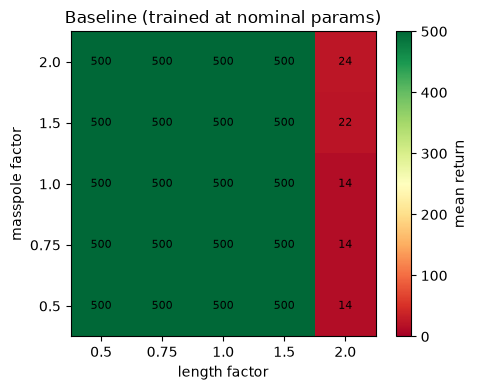

25 个参数组合中，5 个未达 400 分 —— 这就是 reality gap 的量化样子


In [3]:
import matplotlib.pyplot as plt

FACTORS = [0.5, 0.75, 1.0, 1.5, 2.0]

def robustness_heatmap(model, factors=FACTORS, ax=None, title=""):
    '''在 masspole_factor × length_factor 网格上评估平均回报，画热力图'''
    scores = np.zeros((len(factors), len(factors)))
    for i, fm in enumerate(factors):
        for j, fl in enumerate(factors):
            scores[i, j] = eval_on_env(model, make_env(fm, fl))
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(scores, vmin=0, vmax=500, cmap="RdYlGn", origin="lower")
    ax.set_xticks(range(len(factors)), factors)
    ax.set_yticks(range(len(factors)), factors)
    ax.set_xlabel("length factor"); ax.set_ylabel("masspole factor"); ax.set_title(title)
    for i in range(len(factors)):
        for j in range(len(factors)):
            ax.text(j, i, f"{scores[i, j]:.0f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, label="mean return")
    return scores

scores_base = robustness_heatmap(baseline, title="Baseline (trained at nominal params)")
plt.tight_layout(); plt.show()
n_fail = int((scores_base < 400).sum())
print(f"25 个参数组合中，{n_fail} 个未达 400 分 —— 这就是 reality gap 的量化样子")

典型现象：标称点附近一片满分，但**杆长加倍**（length ×2.0 一整列）时回报从 500
崩到十几分——动力学参数改变后，策略「背下」的控制律完全失效。值得玩味的是，
本任务中杆**质量**扰动几乎无感：**哪个参数致命是任务相关的，只能扫出来、不能拍脑袋**，
这正是画热力图而不是凭直觉选随机化参数的原因。

### 第三步：域随机化训练（CPU 约 3–5 分钟）

每次 reset 时把杆质量与杆长都在 [0.6, 1.8] 倍标称值内均匀采样——
策略从此不知道「下一局的世界」长什么样，只能学一套对整片区域都成立的控制律。

In [4]:
dr_env = DomainRandomizeWrapper(
    gym.make("CartPole-v1"),
    masspole_range=(0.6, 1.8),   # 杆质量：标称值的 0.6–1.8 倍
    length_range=(0.6, 1.8),     # 杆长：  标称值的 0.6–1.8 倍
    seed=0,
)
dr_model = PPO("MlpPolicy", dr_env, seed=7, verbose=0, device="cpu")
dr_model.learn(total_timesteps=100_000)
dr_env.close()

r_nominal = eval_on_env(dr_model, make_env())
print(f"DR 策略在标称参数下的回报：{r_nominal:.1f} / 500（与 baseline 标称成绩相当或略低——鲁棒性的代价有时几乎为零）")

DR 策略在标称参数下的回报：500.0 / 500（与 baseline 标称成绩相当或略低——鲁棒性的代价有时几乎为零）


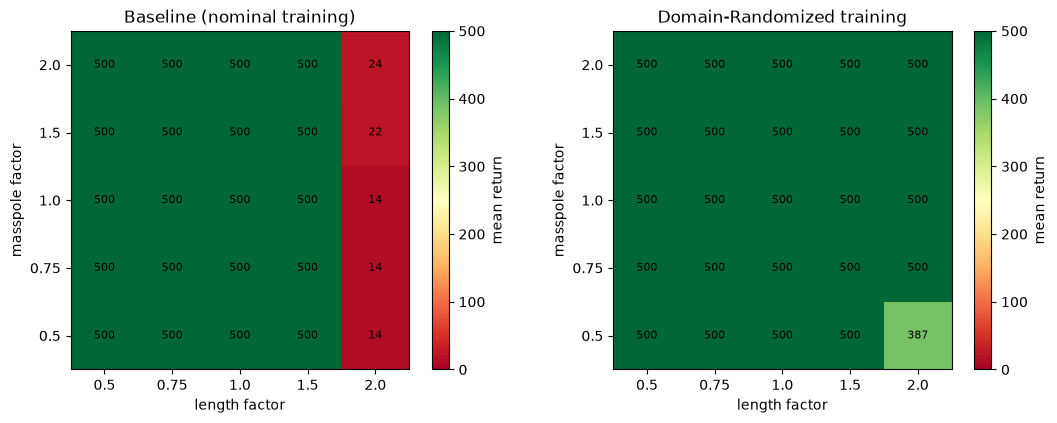

网格平均分：baseline 404  →  DR 495
达标率（≥400 分）：baseline 80%  →  DR 96%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
robustness_heatmap(baseline, ax=axes[0], title="Baseline (nominal training)")
scores_dr = robustness_heatmap(dr_model, ax=axes[1], title="Domain-Randomized training")
plt.tight_layout(); plt.show()

print(f"网格平均分：baseline {scores_base.mean():.0f}  →  DR {scores_dr.mean():.0f}")
print(f"达标率（≥400 分）：baseline {(scores_base >= 400).mean():.0%}  →  DR {(scores_dr >= 400).mean():.0%}")

对比两张热力图：baseline 崩塌的 length ×2.0 一整列被 DR 策略几乎完全救回
（DR 训练覆盖了 [0.6, 1.8]，2.0 已在分布边缘，仍基本保持高分）。
**这就是域随机化的全部核心**：策略不再绑定某一组具体参数，
而是对参数分布 $p(\xi)$ 内的一整片区域负责。
注意分布边缘之外（如极端角点）性能仍会打折——DR 不承诺覆盖训练范围外的世界。

> 思考：如果真实机器人的参数恰好落在标称值附近，DR 是不是「亏了」？是的——
> 这就是 W17 系统辨识存在的意义：把 $p(\xi)$ 的分布范围收缩到真机参数附近，
> DR 只需覆盖剩余的不确定度，少付「鲁棒性税」。

## 3.4 MotrixSim 的参数随机化 API

MotrixSim 原生支持在多环境并行仿真中为**每个实例**设置不同的物理参数
（[官方文档 · 参数随机化](https://motrixsim.readthedocs.io/zh-cn/latest/user_guide/main_function/randomization.html)）。
核心设计：**所有 override 都作用于 `SceneData` 而非 `SceneModel`**——
同一个模型在不同实例中拥有不同参数，无需重新加载模型（回忆 W13 的图纸/工地类比）。

已支持的随机化参数（均带 batch 维度）：

| 属性 | 对象 | 设置方法 | 数据维度 |
|------|------|----------|----------|
| 质量 | Link | `set_mass_override` | `(batch,)` |
| 质心 | Link | `set_center_of_mass_override` | `(batch, 3)` |
| 摩擦力 | Geom | `set_friction_override` | `(batch, 3)`（slide/spin/roll） |
| 几何体尺寸 | Geom | `set_size_override` | `(batch, N)` |
| 电枢惯量 | Joint | `set_armature_override` | `(batch,)` |
| 关节摩擦损耗 | Joint | `set_frictionloss_override` | `(batch,)` |
| 比例增益 Kp | Actuator | `set_kp_override` | `(batch,)` |
| 阻尼增益 Kd | Actuator | `set_damping_override` | `(batch,)` |
| 重力 | SceneModel | `set_gravity_override` | `(batch, 3)` |

> **运行前提**：本机已安装 MotrixSim 及示例模型；以下 cell 保持未执行。
>
> **预期输出**：16 个仿真实例获得互不相同的质量/摩擦/增益/重力参数；
> 断言行（`np.allclose`）全部通过；若接渲染器可看到 16 个实例的运动差异
> （重球下落慢、低摩擦盒上的球滑得更远等）。

In [ ]:
# ⚠️ 运行前提：本机已安装 motrixsim 及示例模型；本 cell 保持未执行
import motrixsim as mx
import numpy as np

model = mx.load_model("examples/assets/randomize/ball_on_box.xml")

# 16 个并行实例；所有 override 数组都带 batch 维
data = mx.SceneData(model, batch=(16,))

# ① 连杆质量随机化：每个实例的球质量 ∈ [0.1, 500]
ball = model.get_link(0)
mass = np.random.uniform(0.1, 500.0, size=(16,)).astype(np.float32)
ball.set_mass_override(data, mass)
assert np.allclose(ball.get_mass_override(data), mass)

# ② 地面摩擦随机化：slide 摩擦从 0.01（冰面）到 2.0（橡胶）
geom = model.get_geom("box_geom")
frictions = np.zeros((16, 3), dtype=np.float32)
frictions[:, 0] = np.linspace(0.01, 2.0, 16)
geom.set_friction_override(data, frictions)

# ③ 关节电枢惯量随机化：影响关节动态响应速度（模拟真实电机转子惯量差异）
joint = model.get_joint("rotor_joint")
armature = np.linspace(0.1, 5.0, 16).astype(np.float32)
joint.set_armature_override(data, armature)

# ④ 执行器 Kp/Kd 随机化：模拟真实伺服增益的个体差异与整定误差
actuator = model.get_actuator("servo")
actuator.set_kp_override(data, np.random.uniform(8.0, 12.0, 16).astype(np.float32))
actuator.set_damping_override(data, np.random.uniform(0.8, 1.2, 16).astype(np.float32))

# ⑤ 重力随机化：大小不变、方向微扰（模拟安装倾斜/IMU 标定误差）
gravity = np.random.randn(16, 3).astype(np.float32)
gravity /= np.linalg.norm(gravity, axis=1, keepdims=True)
gravity *= 9.81
model.set_gravity_override(data, gravity)

print("16 个实例的物理参数已各自独立设置完成")

## 3.5 实操要点与局限

**随机化什么、范围多大**——工程经验排序：

1. **优先随机化「测不准且影响大」的参数**：接触摩擦、执行器增益、电枢惯量、质量/质心；
2. **范围从误差估计来**：能称重的就 ±5%，称不了的（如摩擦）给宽一点（一个数量级）；
   范围太宽会让任务变得不可学（策略干脆「摆烂」取保守行为），太窄则白做；
3. **课程式扩大范围**：先小范围训到收敛，再逐步放宽（OpenAI 的 Automatic Domain
   Randomization 自动做这件事）；

**DR 的局限**：

- 它让策略对「参数集合内最坏情况附近的平均表现」负责，但不保证所有点都满分——
  分布边缘的性能仍可能打折；
- 对**结构性**差异（未建模的柔性、间隙、新地形）无能为力——那不是参数问题；
- 范围确定依赖先验，拍脑袋的范围 = 隐形的过拟合。这正是下一讲的切入点：
  观测噪声与延迟这类「信息通道」上的 gap，需要与动力学 DR 分开处理。

## ✏️ 练习

**E1（★，约 15 分钟）｜范围加倍**
把 DR 训练的采样范围改为 `masspole_range=(0.25, 4.0)`、`length_range=(0.25, 4.0)` 重训，
重画热力图。
**交付物**：新热力图 + 一句话回答：范围扩大后，标称点的回报是升了还是降了？为什么？

**E2（★★，约 30 分钟）｜随机化执行器**
真实电机推力永远不等于标称值。在 `DomainRandomizeWrapper` 中增加 `force_mag` 的随机化
（±30%），重训并对比。
**交付物**：修改后的 wrapper 代码 + force_mag 扰动网格（1×5 即可）上 baseline/DR 回报对比表。

**E3（★★，约 30 分钟）｜设计四足 DR 方案**
参考 3.4 的参数表，为 `dm-quadruped-walk` 任务设计域随机化方案：列出你会随机化的 5 个参数、
建议范围、以及每个参数的「真机误差来源」。
**交付物**：一张五列表格（参数 / 对象 / 范围 / 误差来源 / 预期影响）。

**E4（★★★，约 45 分钟）｜课程式 DR**
实现课程式域随机化：训练步数从 0 到 25k 的过程中，随机化范围从 ±10% 线性扩大到 ±100%。
与固定 ±100% 范围的 DR 对比标称点与边缘点的回报。
**交付物**：实现代码 + 两种方案在 (1.0,1.0) 与 (2.0,2.0) 两点的回报对比 + 3 句结论。

<details>
<summary>参考答案</summary>

**E1**：标称点回报通常**下降**。原因：要覆盖的参数区域变大，策略容量被分摊到更多
「可能的世界」上，分配给标称动力学附近的「专项优化」变少；极端参数（如 4 倍质量、
0.25 倍杆长的组合）甚至可能让任务接近不可控，拖低整体学习信号。这印证了
「范围从误差估计来，不要盲目加宽」的实操原则。

**E2**：wrapper 的 `reset` 中增加一行
`u.force_mag = NOMINAL["force_mag"] * self.rng.uniform(0.7, 1.3)`。
预期现象：baseline 在 force_mag 缩小（0.7×）时退化更明显——推力不足时纠正动作
来不及把杆救回来；DR 后整行回报变平。

**E3**（示例答案，合理即可）：

| 参数 | 对象 | 范围 | 误差来源 | 预期影响 |
|------|------|------|----------|----------|
| 躯干/腿质量 | Link | ±10% | 电池、外壳装配 | 惯量与步态周期 |
| 质心偏移 | Link | ±2 cm | 线缆、传感器布局 | 平衡裕度 |
| 足底摩擦 | Geom | 0.4–1.2 | 地面材质/湿度 | 打滑、推进效率 |
| 电枢惯量 | Joint | 0.5×–2× | 电机型号/减速器 | 关节响应快慢 |
| 执行器 Kp/Kd | Actuator | ±20% | 驱动器整定差异 | 跟踪刚度与抖动 |

**E4**：实现要点——自定义 SB3 Callback，在 `on_step` 里按 `num_timesteps / total_timesteps`
进度线性插值 wrapper 的 range（如 `masspole_range = (1-r, 1+r)`，r 从 0.1 到 1.0）。
预期结论：课程式 DR 在标称点回报更高（早期专注学「会站杆」这个基本技能），
边缘点与固定范围 DR 相当或略好，训练曲线前期上升更快——先学容易的，再泛化，
与人类教学顺序一致。

</details>

## 延伸阅读

- [MotrixSim 文档 · 参数随机化](https://motrixsim.readthedocs.io/zh-cn/latest/user_guide/main_function/randomization.html) —— 3.4 节 API 的官方出处，含质量/质心/摩擦/电枢/增益/重力各示例
- 论文：Domain Randomization 开山之作（[Tobin et al., 2017](https://arxiv.org/abs/1703.06907)）—— 视觉域随机化
- 论文：动力学随机化 Sim-to-Real（[Peng et al., 2018](https://arxiv.org/abs/1710.06537)）—— 机械臂推动态参数随机化
- 论文：Automatic Domain Randomization（[OpenAI et al., 2019](https://arxiv.org/abs/1910.07113)）—— 魔方机械手，DR 范围自动扩大
- 综述：Sim-to-Real Transfer in Deep RL for Robotics（[Zhao et al., 2020](https://arxiv.org/abs/2009.13303)）—— 本阶段三讲（W15–W17）的总地图